# PPMAE Demo – OCT Progression Prediction

This notebook demonstrates the full inference pipeline:
- OCT image preprocessing (retina segmentation + flattening + alignment).
- "Future" OCT reconstruction using Patch Progression MAE (PPMAE)
- Qualitative visualization of results

In [1]:
# Import required libraries 
import os
from pathlib import Path
import sys

import warnings
# Disable noisy warnings from TensorFlow/Keras-based OCTIP dependencies.
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

from IPython.utils import io

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Add the project root to PYTHONPATH 
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

# Import the OCTIP localizers and preprocessing module used for retina alignment.
from utils.octip_segmentation_2d.octip.retina_localizer import RetinaLocalizer, RetinaLocalizationDataset
from utils.octip_segmentation_2d.octip.pre_processor import PreProcessor

# Import PPMAE model
from utils.mae_model import PatchProgressionAutoencoderViT

Segmentation Models: using `keras` framework.


In [2]:
# Imagenet Normalisation
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std = np.array([0.229, 0.224, 0.225])

# Load the PPMAE model checkpoint and switch the model to evaluation mode.
CHECKPOINT_PATH = "../utils/ppmae_models/ppmae_vit_large_v2.pth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
##  Model Loading PPMAE
model_mae = PatchProgressionAutoencoderViT()
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
load_msg = model_mae.load_state_dict(checkpoint, strict=False)
print(load_msg)

model_mae = model_mae.to(DEVICE).eval()

<All keys matched successfully>


In [4]:
##  Model Loading OCTIP

# Define the local OCTIP model directory used by the segmentation-based preprocessing.
OCTIP_MODEL_DIR = "../utils/octip_models/"

# Initialize the two OCTIP localizers and the retina preprocessor.
localizer1 = RetinaLocalizer("FPN", "efficientnetb6", (384, 384), model_directory=OCTIP_MODEL_DIR)
localizer2 = RetinaLocalizer("FPN", "efficientnetb7", (320, 320), model_directory=OCTIP_MODEL_DIR)
preprocessor = PreProcessor(200, min_height=100, normalize_intensities=True)

In [5]:
# Define a few local image pairs 
SAMPLES = [
    {
        "case_id": "example_0", # label = 0
        "t0": "../data/Task_1/test/2F4B0DB0.png",
        "t1": "../data/Task_1/test/25B26370.png",
    },
    {
        "case_id": "example_1", # label = 1
        "t0": "../data/Task_1/test/284CD300.png",
        "t1": "../data/Task_1/test/141DE4A0.png",
    },
    {
        "case_id": "example_2", #label = 2
        "t0": "../data/Task_1/test/2A9120A0.png",
        "t1": "../data/Task_1/test/223ABA60.png",
    },
]

In [6]:
# OCTIP Helpers

# Run OCTIP preprocessing on a single OCT image path.
def run_octip(image_path, localizer1, localizer2, preprocessor):
    with io.capture_output():
        _, seg1_imgs = localizer1(
            RetinaLocalizationDataset([image_path], 6, localizer1)
        )
        _, seg2_imgs = localizer2(
            RetinaLocalizationDataset([image_path], 6, localizer2)
        )

    seg1_imgs = (seg1_imgs.squeeze() * 255).astype("uint8")
    seg2_imgs = (seg2_imgs.squeeze() * 255).astype("uint8")

    try:
        processed = preprocessor(image_path, [seg1_imgs, seg2_imgs], output_directory="")
    except Exception as e:
        print(f"OCTIP preprocessing failed: {e}")
        processed = cv2.imread(image_path, 0)

    raw = cv2.imread(image_path, 0)

    return {
        "raw": raw,
        "mask1": seg1_imgs,
        "mask2": seg2_imgs,
        "processed": processed,
    }

# Define a helper to display the raw OCT image, segmentation masks, and processed output.
def show_octip_result(result, title=""):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(result["raw"], cmap="gray", aspect="auto")
    axes[0].set_title("Raw OCT")
    axes[0].axis("off")

    axes[1].imshow(result["mask1"], cmap="gray", aspect="auto")
    axes[1].set_title("Mask 1")
    axes[1].axis("off")

    axes[2].imshow(result["mask2"], cmap="gray", aspect="auto")
    axes[2].set_title("Mask 2")
    axes[2].axis("off")

    axes[3].imshow(result["processed"], cmap="gray", aspect="auto")
    axes[3].set_title("OCTIP output")
    axes[3].axis("off")

    if title:
        fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

In [7]:
# PPMAE Helpers

# Prepare one OCT image as PPMAE input.
def prepare_ppmae_input(image_t0):
    img = Image.fromarray(image_t0)
    img = img.resize((224, 224))
    img = np.array(img).astype(np.float32) / 255.0

    img = np.expand_dims(img, axis=-1)
    img = np.repeat(img, 3, axis=-1)

    img = img - imagenet_mean
    img = img / imagenet_std

    x = torch.tensor(img)
    x = x.unsqueeze(dim=0)
    x = torch.einsum("nhwc->nchw", x)

    return x.float()

# Run PPMAE from one OCT image and reconstruct the predicted t1 image.
@torch.no_grad()
def run_ppmae(octip_t0, model_mae, image_size=(224, 224), device="cpu", mask_ratio=0.25):
    x = prepare_ppmae_input(octip_t0).to(device)

    model_mae.eval()
    loss, pred, mask = model_mae(x, x, mask_ratio=mask_ratio)

    # Keep a copy for masked visualization
    x_patch = model_mae.patchify(x).float()
    x_patch_masked = x_patch.clone()

    # Put predicted patches back into masked positions
    x_patch[mask == 0] = pred

    # Build reconstructed future image
    x_rec = model_mae.unpatchify(x_patch)
    x_rec = torch.einsum("nchw->nhwc", x_rec).detach().cpu()
    img_t1 = x_rec.squeeze(0).numpy()

    # Reverse normalization
    img_t1 = (img_t1 * imagenet_std + imagenet_mean) * 255
    img_t1 = img_t1[:, :, 1]

    # Build masked t0 visualization
    # Gray blocks on masked patches
    x_patch_masked[mask == 0] = 0.0
    x_masked = model_mae.unpatchify(x_patch_masked)
    x_masked = torch.einsum("nchw->nhwc", x_masked).detach().cpu().numpy()[0]

    x_masked = (x_masked * imagenet_std + imagenet_mean) * 255.0
    t0_masked = x_masked[:, :, 1]

    # Resize to target display size
    pred_t1 = cv2.resize(img_t1, image_size)
    t0_masked = cv2.resize(t0_masked, image_size)

    # Normalize to uint8 for plotting
    pred_t1 = np.array(cv2.normalize(pred_t1, None, 0, 255, cv2.NORM_MINMAX), dtype=np.uint8)
    t0_masked = np.array(cv2.normalize(t0_masked, None, 0, 255, cv2.NORM_MINMAX), dtype=np.uint8)

    return {
        "loss": float(loss.detach().cpu().item()),
        "pred_t1": pred_t1,
        "t0_masked": t0_masked,
        "mask": mask.detach().cpu(),
    }


def ppmae_visualization(sample, t0, t0_masked, pred_t1, t1, loss=None):
    
    display_size = (224, 224)
    # Resize 
    t0 = cv2.resize(t0, display_size)
    t1 = cv2.resize(t1, display_size)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    titles = ["Image T0", "Image T0 Masked", "Predicted T+1", "Ground Truth T+1"]
    images = [t0, t0_masked, pred_t1, t1]

    for i in range(4):
        axes[i].imshow(images[i], cmap="gray")
        axes[i].set_title(titles[i], fontsize=11)
        axes[i].axis("off")

    if loss is not None:
        fig.suptitle(f'{sample["case_id"]} | loss={loss:.4f}', fontsize=13)
    else:
        fig.suptitle(sample["case_id"], fontsize=13)

    plt.tight_layout()
    plt.show()

## OCTIP Visualization

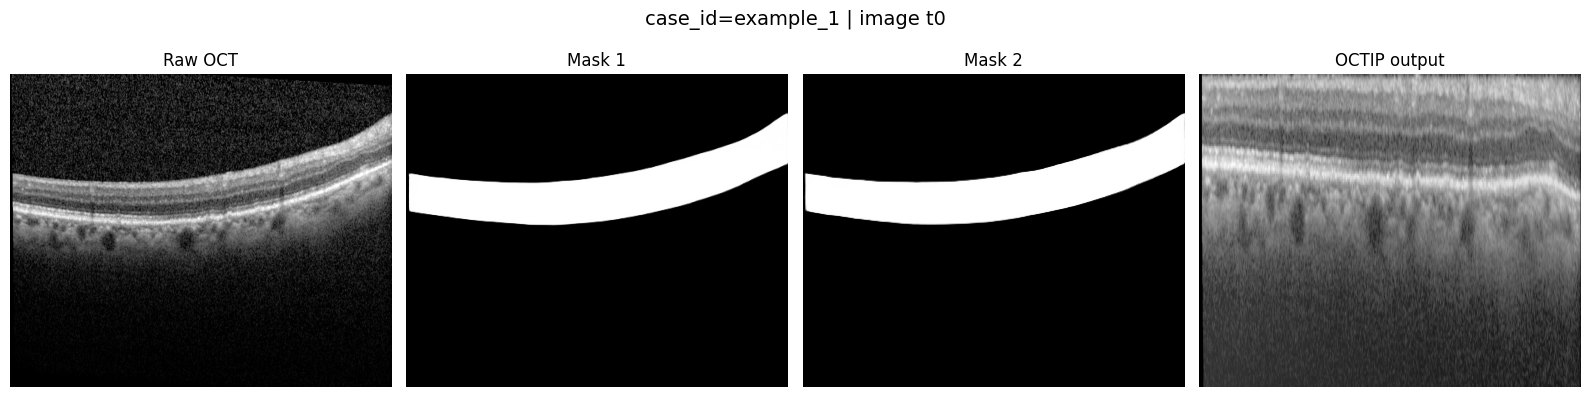

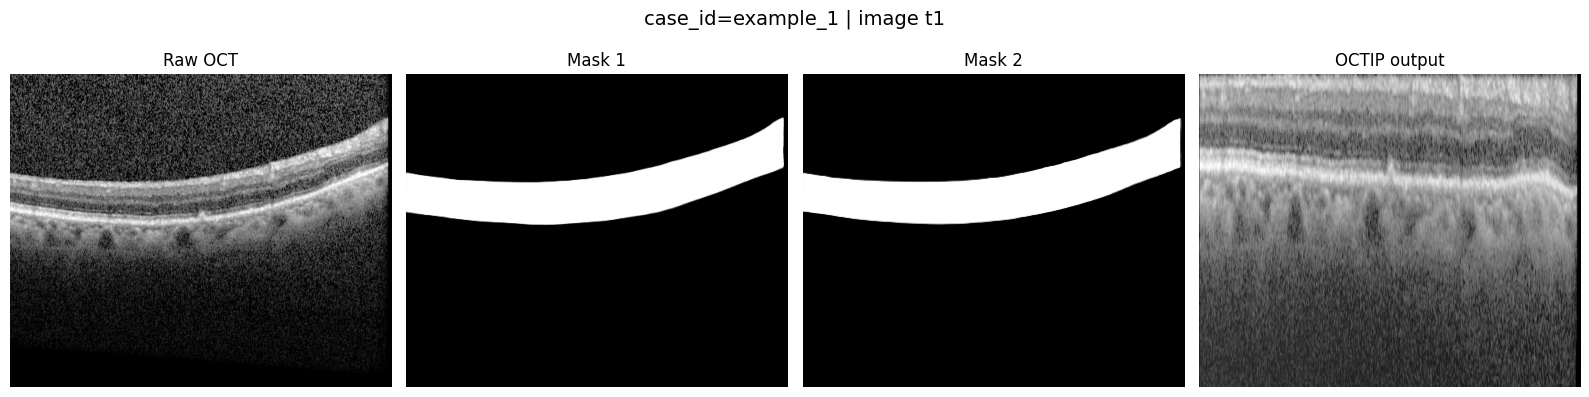

In [8]:
# Process one manually selected sample.
sample = SAMPLES[1]

# OCTIP on t0
result_t0 = run_octip(sample["t0"], localizer1, localizer2, preprocessor)
show_octip_result(result_t0, title=f'case_id={sample["case_id"]} | image t0')

# OCTIP on t1
result_t1 = run_octip(sample["t1"], localizer1, localizer2, preprocessor)
show_octip_result(result_t1, title=f'case_id={sample["case_id"]} | image t1')

## PPMAE Visualization 

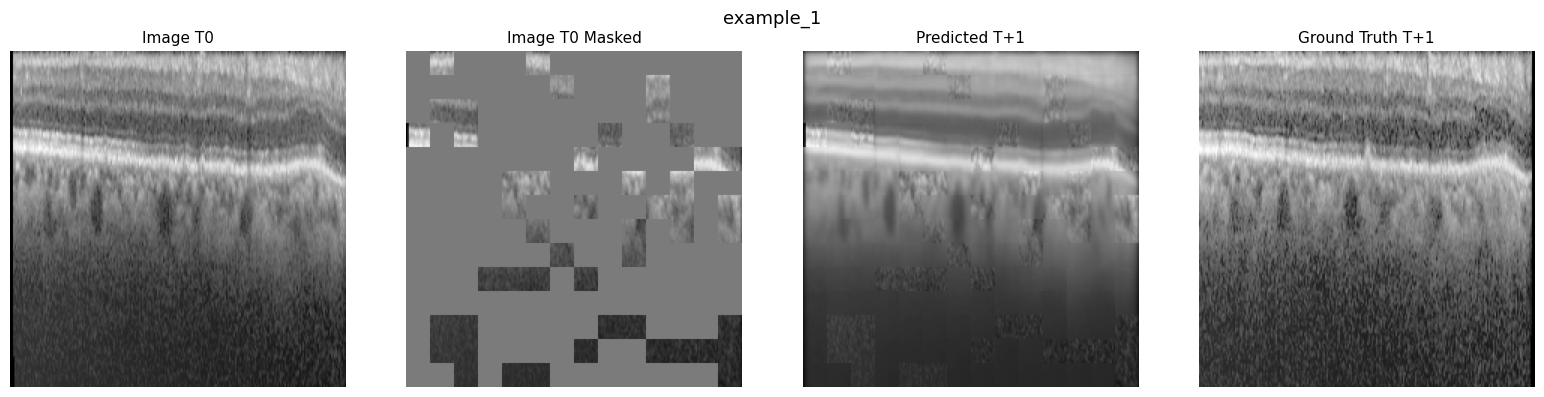

Reconstruction loss: 0.03688278794288635


In [9]:
# Pick one sample
sample = SAMPLES[1]

# OCTIP preprocessing
result_t0 = run_octip(sample["t0"], localizer1, localizer2, preprocessor)
result_t1 = run_octip(sample["t1"], localizer1, localizer2, preprocessor)

octip_t0, octip_t1 = result_t0["processed"], result_t1["processed"] # (200, 1024)

# PPMAE inference on 224x224 images
ppmae_result = run_ppmae(octip_t0, model_mae, image_size=(224, 224), device=DEVICE, mask_ratio=0.25)

loss = ppmae_result["loss"]
t0_masked = ppmae_result["t0_masked"]
pred_t1 = ppmae_result["pred_t1"]

# Visualization
ppmae_visualization(sample, octip_t0, t0_masked, pred_t1, octip_t1)

print("Reconstruction loss:", loss)